___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Quick Guide to Facebook's Prophet Basics
---
---

## IMPORTANT NOTE ONE:

**You should really read the papaer for Prophet! It is relatively straightforward and has a lot of insight on their techniques on how Prophet works internally!**

Link to paper: https://peerj.com/preprints/3190.pdf
---
---

## IMPORTANT NOTE TWO:

-----
------

* **NOTE: Link to installation instructions:** 
    * https://facebook.github.io/prophet/docs/installation.html#python 
    * SCROLL DOWN UNTIL YOU SEE THE ANACONDA OPTION AT THE BOTTOM OF THE PAGE.
    * YOU MAY NEED TO INSTALL BOTH **conda install gcc** and **conda install -c conda-forge fbprophet**
    * PLEASE READ THROUGH THE DOCS AND STACKOERFLOW CAREFULLY BEFORE POSTING INSTALLATION ISSUES TO THE QA FORUMS.

-----
----

## Load Libraries

In [8]:
import pandas as pd
from prophet import Prophet


## Load Data

The input to Prophet is always a dataframe with two columns: ds and y. The ds (datestamp) column should be of a format expected by Pandas, ideally YYYY-MM-DD for a date or YYYY-MM-DD HH:MM:SS for a timestamp. The y column must be numeric, and represents the measurement we wish to forecast.

In [20]:
df = pd.read_csv('../Data/BeerWineLiquor.csv')

In [21]:
df.head()

,date,beer
0,1/1/1992,1509
1,2/1/1992,1541
2,3/1/1992,1597
3,4/1/1992,1675
4,5/1/1992,1822


### Format the Data

In [5]:
df.columns = ['ds','y']

In [6]:
df['ds'] = pd.to_datetime(df['ds'])

## Create and Fit Model

In [9]:
# This is fitting on all the data (no train test split in this example)
m = Prophet()
m.fit(df)

17:39:41 - cmdstanpy - INFO - Chain [1] start processing
17:39:41 - cmdstanpy - INFO - Chain [1] done processing


## Forecasting

### Step 1: Create "future" placeholder dataframe

**NOTE: Prophet by default is for daily data. You need to pass a frequency for sub-daily or monthly data. Info: https://facebook.github.io/prophet/docs/non-daily_data.html**

In [10]:
# placeholder to hold our future predictions
future = m.make_future_dataframe(periods=24,freq = 'MS') # periods: how long we want to predict

In [8]:
df.tail()

,ds,y
319,2018-08-01,4898
320,2018-09-01,4598
321,2018-10-01,4737
322,2018-11-01,5130
323,2018-12-01,6370


In [9]:
future.tail()

,ds
343,2020-08-01
344,2020-09-01
345,2020-10-01
346,2020-11-01
347,2020-12-01


In [10]:
len(df)

324

In [11]:
len(future)

348


### Step 2: Predict and fill in the Future

In [13]:
forecast = m.predict(future)

In [14]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-01-01,1776.688550,1150.782396,1480.442625,1776.688550,1776.688550,-461.851026,-461.851026,-461.851026,-461.851026,-461.851026,-461.851026,0.0,0.0,0.0,1314.837524
1,1992-02-01,1779.325501,1192.778446,1504.586336,1779.325501,1779.325501,-427.596930,-427.596930,-427.596930,-427.596930,-427.596930,-427.596930,0.0,0.0,0.0,1351.728571
2,1992-03-01,1781.792325,1442.185572,1752.092387,1781.792325,1781.792325,-179.353792,-179.353792,-179.353792,-179.353792,-179.353792,-179.353792,0.0,0.0,0.0,1602.438533
3,1992-04-01,1784.429276,1429.649717,1747.738637,1784.429276,1784.429276,-196.121536,-196.121536,-196.121536,-196.121536,-196.121536,-196.121536,0.0,0.0,0.0,1588.307740
4,1992-05-01,1786.981164,1674.456523,1985.874956,1786.981164,1786.981164,45.427321,45.427321,45.427321,45.427321,45.427321,45.427321,0.0,0.0,0.0,1832.408485


In [14]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
343,2020-08-01,5201.010945,5074.524666,5397.039919,5190.005465,5213.185170,40.218725,40.218725,40.218725,40.218725,40.218725,40.218725,0.0,0.0,0.0,5241.229670
344,2020-09-01,5217.085200,4932.976994,5246.885844,5205.065711,5230.470140,-132.884136,-132.884136,-132.884136,-132.884136,-132.884136,-132.884136,0.0,0.0,0.0,5084.201064
345,2020-10-01,5232.640931,5037.574360,5361.483095,5219.696878,5247.521702,-43.275393,-43.275393,-43.275393,-43.275393,-43.275393,-43.275393,0.0,0.0,0.0,5189.365538
346,2020-11-01,5248.715186,5168.423030,5502.051767,5234.716079,5264.968845,86.703091,86.703091,86.703091,86.703091,86.703091,86.703091,0.0,0.0,0.0,5335.418277
347,2020-12-01,5264.270916,6160.467499,6497.079944,5249.311816,5281.695680,1071.508751,1071.508751,1071.508751,1071.508751,1071.508751,1071.508751,0.0,0.0,0.0,6335.779667


In [15]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [16]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
336,2020-01-01,4628.788552,4471.253028,4805.818068
337,2020-02-01,4679.048478,4507.791210,4844.742347
338,2020-03-01,4942.495400,4783.785125,5110.230608
339,2020-04-01,4941.439371,4772.041628,5107.288259
340,2020-05-01,5198.333619,5037.037450,5358.603793
341,2020-06-01,5179.412285,5009.729943,5337.560681
342,2020-07-01,5311.959526,5151.814252,5480.267144
343,2020-08-01,5241.229670,5074.524666,5397.039919
344,2020-09-01,5084.201064,4932.976994,5246.885844
345,2020-10-01,5189.365538,5037.574360,5361.483095


### Plotting Forecast

We can use Prophet's own built in plotting tools

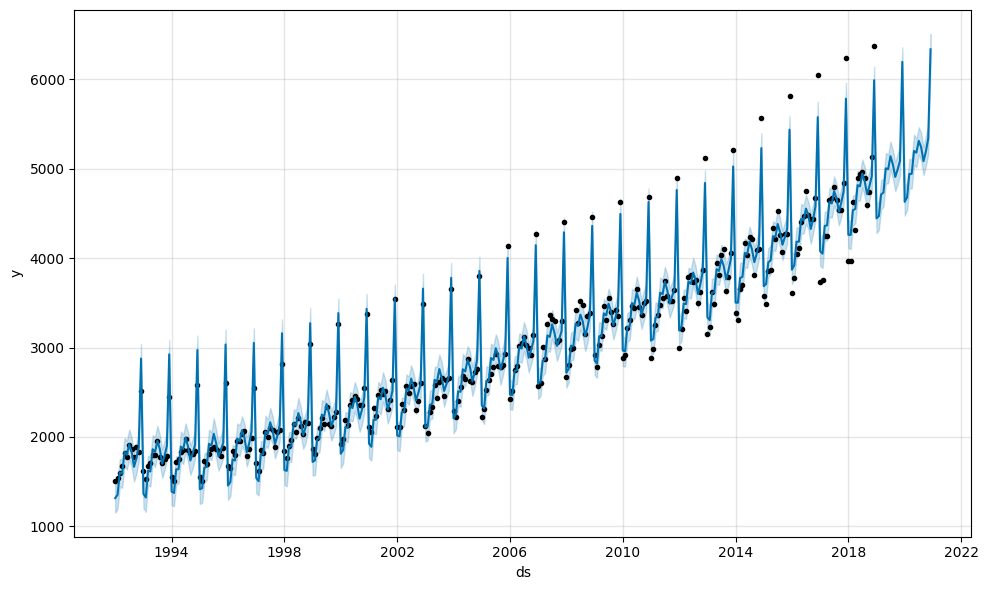

In [15]:
m.plot(forecast);

(16071.0, 18993.0)

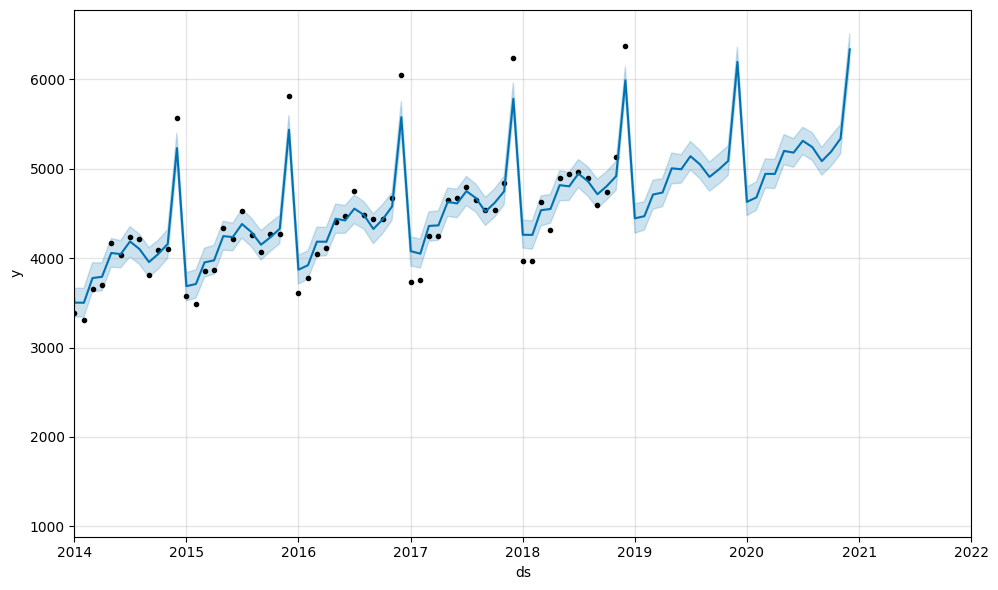

In [17]:
import matplotlib.pyplot as plt
# Convert string dates to datetime
start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2022-01-01')

m.plot(forecast)
plt.xlim(start_date, end_date)

<Axes: xlabel='ds'>

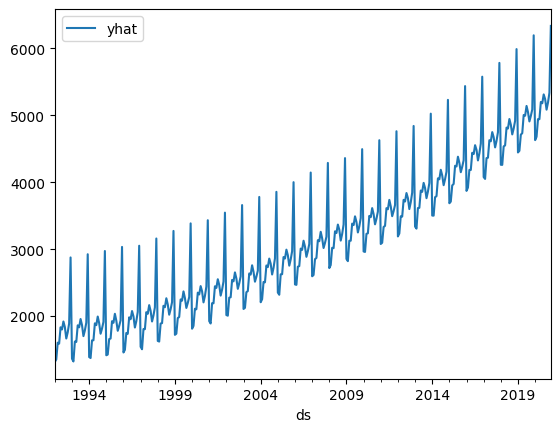

In [18]:
forecast.plot(x='ds',y='yhat')

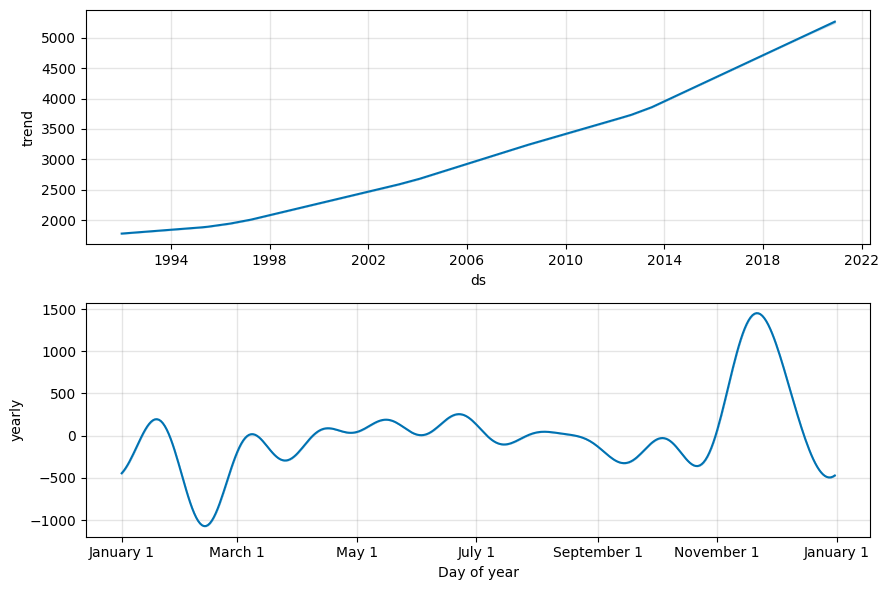

In [19]:
m.plot_components(forecast);


## Great Job!